# French WinoWhat Replication: Model Evaluation on Original and Paraphrased French Winograd Data

## Overview

This notebook replicates the WinoWhat framework (Gevers et al., 2025) in French using a combined dataset of 200 instances drawn from two sources:

French Winograd Schemas (Amsili & Seminck, 2017): 100 instances parsed from the original XML file. These are Google-proof French Winograd schemas designed for commonsense coreference resolution.
WinoWhat validation subset translated into French (Gevers et al., 2025): 100 instances from the English WinoWhat dataset, translated using the DeepL API.

### Dataset structure

The original French Winograd schemas use pronoun-based coreference sentences (a pronoun must be resolved to one of two candidate antecedents). To align with the WinoWhat framework, which uses a fill-in-the-blank token (_), each sentence was converted: the ambiguous pronoun was replaced by _, and the two candidate antecedents became option1 and option2. This conversion preserves the commonsense disambiguation task while matching the surface format of WinoGrande. The translated WinoWhat instances already follow this format.

### Paraphrases

Each sentence was manually paraphrased to produce a meaning-preserving variant in which the `_` token appears at the end of the sentence. This mirrors the WinoWhat corpus design and removes the positional dependency of the partial evaluation metric on tokens that follow the blank. All paraphrases were checked for grammaticality and preservation of ambiguity.

### Evaluation methods

Two model families are evaluated:

- **Causal LMs (Mistral-7B): Partial evaluation.** The scoring follows the implementation of Gevers et al. (2025) (`run_llm.py`). For each instance and each option, the text before `_` is the context. The summed log-likelihood of the option tokens is computed using `tokenizer.encode` with `add_special_tokens=False`, and log-probabilities are extracted with `torch.gather` on the shifted logits. This matches the scoring method used in the original WinoWhat paper and the LM Evaluation Harness.

- **Masked LMs (CamemBERT): Pseudo-log-likelihood (PLL).** Each completed sentence is scored by masking one token at a time and summing log P(token | rest of sentence). This is the standard evaluation protocol for encoder-only models. The two scoring methods are not directly comparable in absolute value, but both answer the same question: which completed sentence does the model prefer?

### Statistical reporting

Confidence intervals use the Wilson score interval (more reliable than the normal approximation for moderate n). Significance of the original vs. paraphrase performance drop is assessed with McNemar's exact test, which is appropriate for paired binary predictions on the same instances.

In [1]:
# Install required libraries
!pip -q install transformers accelerate sentencepiece pandas tqdm statsmodels

In [2]:
import os
import math
import random
import numpy as np
import pandas as pd
import torch

from tqdm.auto import tqdm
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForMaskedLM
)
from google.colab import drive, files

# Reproducibility
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [3]:
drive.mount('/content/drive')

csv_path = "/content/drive/MyDrive/Thesis_2025/new/french_wino_with_paraphrases.csv"
df = pd.read_csv(csv_path)

print("Raw rows:", len(df))
print(df.head())

Mounted at /content/drive
Raw rows: 200
   id                                           sentence  \
0   1  La coupe n'entre pas dans la valise marron, ca...   
1   2  Paul a essayé de joindre Georges sur son télép...   
2   3  L'avocat a posé une question au témoin, mais _...   
3   4  Nicolas n'a pas pu soulever son fils car _ éta...   
4   5  Les lycéens harcelaient les collégiens, donc o...   

                                paraphrased_sentence         option1  \
0  Impossible de faire entrer la coupe dans la va...       la valise   
1  Paul a tenté d'appeler Georges sur son portabl...            Paul   
2  L'avocat a posé une question au témoin ; ce de...        l'avocat   
3  Comme _ était trop faible, Nicolas n’a pas réu...         Nicolas   
4  À cause du harcèlement envers les collégiens, ...  les collégiens   

       option2  answer  
0     la coupe       2  
1      Georges       1  
2    le témoin       1  
3     son fils       1  
4  les lycéens       2  


## Dataset Statistics

Before evaluation, we report descriptive statistics of the dataset to document its composition.

In [4]:
# Dataset Statistics

print(f"Total instances:          {len(df)}")
print(f"Instances with answer=1:  {(df['answer'] == 1).sum()} ({(df['answer'] == 1).mean()*100:.1f}%)")
print(f"Instances with answer=2:  {(df['answer'] == 2).sum()} ({(df['answer'] == 2).mean()*100:.1f}%)")
print()

# Sentence length statistics (in tokens, approximated by whitespace split)
df["orig_len"] = df["sentence"].apply(lambda x: len(str(x).split()))
df["para_len"] = df["paraphrased_sentence"].apply(lambda x: len(str(x).split()))

print("Original sentence length (words):")
print(f"  Mean: {df['orig_len'].mean():.1f}  Std: {df['orig_len'].std():.1f}  Min: {df['orig_len'].min()}  Max: {df['orig_len'].max()}")
print("Paraphrased sentence length (words):")
print(f"  Mean: {df['para_len'].mean():.1f}  Std: {df['para_len'].std():.1f}  Min: {df['para_len'].min()}  Max: {df['para_len'].max()}")
print()

# Option length
df["opt1_len"] = df["option1"].apply(lambda x: len(str(x).split()))
df["opt2_len"] = df["option2"].apply(lambda x: len(str(x).split()))
print("Option 1 length (words): Mean", round(df['opt1_len'].mean(), 2))
print("Option 2 length (words): Mean", round(df['opt2_len'].mean(), 2))
print()

# Verify blank format
bad_orig = (df["sentence"].str.count("_") != 1).sum()
bad_para = (df["paraphrased_sentence"].str.count("_") != 1).sum()
print(f"Sentences with != 1 blank (original):    {bad_orig}")
print(f"Sentences with != 1 blank (paraphrased): {bad_para}")

# Check blank position in paraphrased (should be near end)
def blank_position_ratio(text):
    """Returns the relative position of _ in the sentence (0=start, 1=end)."""
    words = str(text).split()
    if "_" not in words:
        return None
    idx = words.index("_")
    return idx / max(len(words) - 1, 1)

df["orig_blank_pos"] = df["sentence"].apply(blank_position_ratio)
df["para_blank_pos"] = df["paraphrased_sentence"].apply(blank_position_ratio)

print()
print(f"Blank position ratio — original:    Mean={df['orig_blank_pos'].mean():.2f} (0=start, 1=end)")
print(f"Blank position ratio — paraphrased: Mean={df['para_blank_pos'].mean():.2f} (should be higher, closer to 1)")

# Example instances

print("EXAMPLE INSTANCES")

for _, row in df.head(3).iterrows():
    print(f"ID {row['id']}")
    print(f"  Original:    {row['sentence']}")
    print(f"  Paraphrased: {row['paraphrased_sentence']}")
    print(f"  Option 1: {row['option1']}  |  Option 2: {row['option2']}  |  Answer: {row['answer']}")
    print()

Total instances:          200
Instances with answer=1:  92 (46.0%)
Instances with answer=2:  108 (54.0%)

Original sentence length (words):
  Mean: 18.8  Std: 5.0  Min: 9  Max: 34
Paraphrased sentence length (words):
  Mean: 20.3  Std: 5.6  Min: 8  Max: 45

Option 1 length (words): Mean 1.48
Option 2 length (words): Mean 1.48

Sentences with != 1 blank (original):    0
Sentences with != 1 blank (paraphrased): 0

Blank position ratio — original:    Mean=0.74 (0=start, 1=end)
Blank position ratio — paraphrased: Mean=0.70 (should be higher, closer to 1)
EXAMPLE INSTANCES
ID 1
  Original:    La coupe n'entre pas dans la valise marron, car _ est trop grande.
  Paraphrased: Impossible de faire entrer la coupe dans la valise marron puisque _ est trop grande.
  Option 1: la valise  |  Option 2: la coupe  |  Answer: 2

ID 2
  Original:    Paul a essayé de joindre Georges sur son téléphone, mais _ n'a pas réussi.
  Paraphrased: Paul a tenté d'appeler Georges sur son portable, cependant _ n’a pas

In [5]:
# Clean and validate data

required_cols = ["id", "sentence", "paraphrased_sentence", "option1", "option2", "answer"]
df = df.dropna(subset=required_cols).copy()

for col in ["sentence", "paraphrased_sentence", "option1", "option2"]:
    df[col] = df[col].astype(str).str.strip()

df["answer"] = df["answer"].astype(int)

print("After cleaning:", len(df))
print("Answer distribution:")
print(df["answer"].value_counts())

bad_original = (df["sentence"].str.count("_") != 1).sum()
bad_para = (df["paraphrased_sentence"].str.count("_") != 1).sum()
print(f"\nBad original rows (blank count != 1): {bad_original}")
print(f"Bad paraphrased rows (blank count != 1): {bad_para}")

if bad_original > 0 or bad_para > 0:
    print("\nDropping malformed rows...")
    df = df[(df["sentence"].str.count("_") == 1) &
            (df["paraphrased_sentence"].str.count("_") == 1)].copy()
    print(f"Rows remaining after drop: {len(df)}")

After cleaning: 200
Answer distribution:
answer
2    108
1     92
Name: count, dtype: int64

Bad original rows (blank count != 1): 0
Bad paraphrased rows (blank count != 1): 0


In [6]:
# Helper functions


def fill_blank(text, option):
    return text.replace("_", option)

def build_completed_sentences(df, text_column):
    data = df.copy()
    data["filled_1"] = data.apply(lambda x: fill_blank(x[text_column], x["option1"]), axis=1)
    data["filled_2"] = data.apply(lambda x: fill_blank(x[text_column], x["option2"]), axis=1)
    return data

def wilson_ci(acc, n, z=1.96):
    """
    Wilson score confidence interval for a proportion.
    Preferred over normal approximation for moderate n and proportions near 0 or 1.
    Returns (lower, upper).
    """
    if n == 0:
        return (0.0, 1.0)
    denominator = 1 + z**2 / n
    centre = (acc + z**2 / (2 * n)) / denominator
    margin = (z / denominator) * math.sqrt(acc * (1 - acc) / n + z**2 / (4 * n**2))
    return (max(0.0, centre - margin), min(1.0, centre + margin))

In [7]:
# Causal LM scorer (Mistral)
# Partial evaluation: summed log-likelihood of the option tokens given the context.
# Scoring method follows Gevers et al. (2025) run_llm.py.
# Key implementation points:
#   - tokenizer.encode with add_special_tokens=False (True only for Gemma)
#   - context length computed from tokenizer output, not from string split
#   - log-probs extracted with torch.gather on shifted logits
#   - evaluate_on_full_continuation=False matches the WinoWhat setting

class CausalPartialScorer:
    def __init__(self, model_name):
        self.model_is_gemma = "gemma" in model_name.lower()
        self.model = AutoModelForCausalLM.from_pretrained(
            model_name,
            revision="main",
            torch_dtype="auto",
            trust_remote_code=False,
            device_map="auto"
        )
        self.model.eval()
        self.model.tie_weights()
        self.tokenizer = AutoTokenizer.from_pretrained(
            model_name,
            revision="main",
            trust_remote_code=False,
            device_map="auto"
        )

    @torch.no_grad()
    def score_option(self, sentence_with_blank, option,
                     evaluate_on_full_continuation=False):
        """
        Compute summed log-likelihood of the option tokens given the context prefix.
        For paraphrased sentences (blank at end) the continuation is the option only.
        For original sentences (blank mid-sentence) evaluate_on_full_continuation
        controls whether the post-option text is also scored (default False).
        """
        add_special = self.model_is_gemma

        parts  = sentence_with_blank.split("_", 1)
        prefix = parts[0]
        suffix = parts[1].strip() if len(parts) > 1 else ""

        if suffix and evaluate_on_full_continuation:
            continuation = option + " " + suffix
        else:
            continuation = option

        full_ids    = self.tokenizer.encode(prefix + continuation,
                                            add_special_tokens=add_special)
        context_ids = self.tokenizer.encode(prefix,
                                            add_special_tokens=add_special)
        continuation_ids = full_ids[len(context_ids):]

        if not continuation_ids:
            return float("-inf")

        max_length = 4096
        inp = torch.tensor(
            (context_ids + continuation_ids)[-(max_length + 1):][:-1],
            dtype=torch.long,
            device=self.model.device
        )
        (inplen,) = inp.shape

        logits    = self.model(inp.unsqueeze(0)).logits.squeeze(0).to(torch.float32)
        log_probs = torch.nn.functional.log_softmax(logits, dim=-1)

        contlen       = len(continuation_ids)
        ctx_len       = inplen + (log_probs.shape[0] - inplen)
        lp_cont       = log_probs[ctx_len - contlen : ctx_len]
        cont_toks     = torch.tensor(continuation_ids, device=self.model.device)
        selected      = torch.gather(
            lp_cont.unsqueeze(0), 2,
            cont_toks.unsqueeze(-1).unsqueeze(0)
        ).squeeze(-1)

        return float(selected.sum())


In [8]:
# Masked LM scorer (CamemBERT)
# Pseudo-log-likelihood: mask each token in turn,
# sum log P(token | rest of sentence).


class MaskedLMScorer:
    def __init__(self, model_name):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForMaskedLM.from_pretrained(model_name).to(self.device)
        self.model.eval()

    @torch.no_grad()
    def score(self, text):
        enc = self.tokenizer(text, return_tensors="pt", truncation=True)
        input_ids = enc["input_ids"].to(self.device)
        attention_mask = enc["attention_mask"].to(self.device)

        seq_len = input_ids.size(1)
        total_log_prob = 0.0

        # Skip special tokens (first and last)
        for i in range(1, seq_len - 1):
            masked_ids = input_ids.clone()
            masked_ids[0, i] = self.tokenizer.mask_token_id

            outputs = self.model(masked_ids, attention_mask=attention_mask)
            logits = outputs.logits

            log_probs = torch.nn.functional.log_softmax(logits[0, i], dim=-1)
            total_log_prob += log_probs[input_ids[0, i]].item()

        return total_log_prob

In [10]:
# Evaluation functions

def evaluate_causal(df, text_column, scorer):
    """Evaluate a causal LM on a given text column using partial evaluation."""
    data = df.copy()
    predictions, score1_list, score2_list = [], [], []

    for _, row in tqdm(data.iterrows(), total=len(data), desc=f"Causal [{text_column}]"):
        s1 = scorer.score_option(row[text_column], row["option1"])
        s2 = scorer.score_option(row[text_column], row["option2"])
        pred = 1 if s1 > s2 else 2
        predictions.append(pred)
        score1_list.append(s1)
        score2_list.append(s2)

    data["pred"] = predictions
    data["score1"] = score1_list
    data["score2"] = score2_list
    data["correct"] = (data["pred"] == data["answer"]).astype(int)
    accuracy = data["correct"].mean()
    return accuracy, data


def evaluate_mlm(df, text_column, scorer):
    """Evaluate a masked LM using pseudo-log-likelihood."""
    data = df.copy()
    predictions, score1_list, score2_list = [], [], []

    for _, row in tqdm(data.iterrows(), total=len(data), desc=f"MLM [{text_column}]"):
        filled1 = fill_blank(row[text_column], row["option1"])
        filled2 = fill_blank(row[text_column], row["option2"])
        s1 = scorer.score(filled1)
        s2 = scorer.score(filled2)
        pred = 1 if s1 > s2 else 2
        predictions.append(pred)
        score1_list.append(s1)
        score2_list.append(s2)

    data["pred"] = predictions
    data["score1"] = score1_list
    data["score2"] = score2_list
    data["correct"] = (data["pred"] == data["answer"]).astype(int)
    accuracy = data["correct"].mean()
    return accuracy, data

In [11]:
# Baselines

random_baseline = 0.50
always_option1_baseline = (df["answer"] == 1).mean()

print("Baselines")
print(f"  Random (chance):   {random_baseline:.4f}")
print(f"  Always option 1:   {always_option1_baseline:.4f}")
print(f"  (answer=1 count: {(df['answer']==1).sum()}/{len(df)}, answer=2 count: {(df['answer']==2).sum()}/{len(df)})")

# Output folder
output_dir = "/content/wino_results"
os.makedirs(output_dir, exist_ok=True)

summary_rows = []

Baselines
  Random (chance):   0.5000
  Always option 1:   0.4600
  (answer=1 count: 92/200, answer=2 count: 108/200)


## Mistral-7B (Causal LM Partial Evaluation)

In [12]:
print("Running Mistral-7B...")
mistral_model_name = "mistralai/Mistral-7B-v0.1"
mistral_scorer = CausalPartialScorer(mistral_model_name)

orig_acc_mistral, orig_results_mistral = evaluate_causal(df, "sentence", mistral_scorer)
para_acc_mistral, para_results_mistral = evaluate_causal(df, "paraphrased_sentence", mistral_scorer)

orig_ci_mistral = wilson_ci(orig_acc_mistral, len(df))
para_ci_mistral = wilson_ci(para_acc_mistral, len(df))
drop_mistral = orig_acc_mistral - para_acc_mistral

print(f"Original accuracy:    {orig_acc_mistral:.4f}  95% CI [{orig_ci_mistral[0]:.4f}, {orig_ci_mistral[1]:.4f}]")
print(f"Paraphrased accuracy: {para_acc_mistral:.4f}  95% CI [{para_ci_mistral[0]:.4f}, {para_ci_mistral[1]:.4f}]")
print(f"Accuracy drop:        {drop_mistral:.4f}")

# Save per-instance results
orig_results_mistral.to_csv(os.path.join(output_dir, "results_original_mistral.csv"), index=False)
para_results_mistral.to_csv(os.path.join(output_dir, "results_paraphrased_mistral.csv"), index=False)

# Error analysis
wrong_orig_mistral = orig_results_mistral[orig_results_mistral["correct"] == 0]
wrong_para_mistral = para_results_mistral[para_results_mistral["correct"] == 0]
wrong_orig_mistral.to_csv(os.path.join(output_dir, "wrong_original_mistral.csv"), index=False)
wrong_para_mistral.to_csv(os.path.join(output_dir, "wrong_paraphrased_mistral.csv"), index=False)

summary_rows.append({
    "model": "Mistral-7B",
    "scorer": "Causal (partial)",
    "orig_acc": orig_acc_mistral,
    "orig_ci_low": orig_ci_mistral[0],
    "orig_ci_high": orig_ci_mistral[1],
    "para_acc": para_acc_mistral,
    "para_ci_low": para_ci_mistral[0],
    "para_ci_high": para_ci_mistral[1],
    "drop": drop_mistral
})

Running Mistral-7B...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Causal [sentence]:   0%|          | 0/200 [00:00<?, ?it/s]

Causal [paraphrased_sentence]:   0%|          | 0/200 [00:00<?, ?it/s]

Original accuracy:    0.4800  95% CI [0.4118, 0.5490]
Paraphrased accuracy: 0.5100  95% CI [0.4412, 0.5784]
Accuracy drop:        -0.0300


In [13]:
# Free GPU memory before loading next model
del mistral_scorer
torch.cuda.empty_cache()

## CamemBERT (Masked LM Pseudo-Log-Likelihood)

In [15]:
print("Running CamemBERT...")
camembert_model_name = "camembert-base"
camembert_scorer = MaskedLMScorer(camembert_model_name)

orig_acc_camembert, orig_results_camembert = evaluate_mlm(df, "sentence", camembert_scorer)
para_acc_camembert, para_results_camembert = evaluate_mlm(df, "paraphrased_sentence", camembert_scorer)

orig_ci_camembert = wilson_ci(orig_acc_camembert, len(df))
para_ci_camembert = wilson_ci(para_acc_camembert, len(df))
drop_camembert = orig_acc_camembert - para_acc_camembert

print(f"Original accuracy:    {orig_acc_camembert:.4f}  95% CI [{orig_ci_camembert[0]:.4f}, {orig_ci_camembert[1]:.4f}]")
print(f"Paraphrased accuracy: {para_acc_camembert:.4f}  95% CI [{para_ci_camembert[0]:.4f}, {para_ci_camembert[1]:.4f}]")
print(f"Accuracy drop:        {drop_camembert:.4f}")

orig_results_camembert.to_csv(os.path.join(output_dir, "results_original_camembert.csv"), index=False)
para_results_camembert.to_csv(os.path.join(output_dir, "results_paraphrased_camembert.csv"), index=False)

wrong_orig_camembert = orig_results_camembert[orig_results_camembert["correct"] == 0]
wrong_para_camembert = para_results_camembert[para_results_camembert["correct"] == 0]
wrong_orig_camembert.to_csv(os.path.join(output_dir, "wrong_original_camembert.csv"), index=False)
wrong_para_camembert.to_csv(os.path.join(output_dir, "wrong_paraphrased_camembert.csv"), index=False)

summary_rows.append({
    "model": "CamemBERT-base",
    "scorer": "Masked (PLL)",
    "orig_acc": orig_acc_camembert,
    "orig_ci_low": orig_ci_camembert[0],
    "orig_ci_high": orig_ci_camembert[1],
    "para_acc": para_acc_camembert,
    "para_ci_low": para_ci_camembert[0],
    "para_ci_high": para_ci_camembert[1],
    "drop": drop_camembert
})

Running CamemBERT...


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

CamembertForMaskedLM LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.decoder.bias        | MISSING    | 
lm_head.decoder.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


MLM [sentence]:   0%|          | 0/200 [00:00<?, ?it/s]

MLM [paraphrased_sentence]:   0%|          | 0/200 [00:00<?, ?it/s]

Original accuracy:    0.5250  95% CI [0.4560, 0.5931]
Paraphrased accuracy: 0.5250  95% CI [0.4560, 0.5931]
Accuracy drop:        0.0000


In [ ]:
# Save summary table
summary_df = pd.DataFrame(summary_rows)
summary_path = os.path.join(output_dir, "summary_results.csv")
summary_df.to_csv(summary_path, index=False)

print("\n" + "=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
print(f"{'Model':<18} {'Scorer':<20} {'Orig':>6} {'CI':>20} {'Para':>6} {'CI':>20} {'Drop':>6}")
print("-" * 100)
for _, r in summary_df.iterrows():
    orig_ci_str = f"[{r['orig_ci_low']:.3f}, {r['orig_ci_high']:.3f}]"
    para_ci_str = f"[{r['para_ci_low']:.3f}, {r['para_ci_high']:.3f}]"
    print(f"{r['model']:<18} {r['scorer']:<20} {r['orig_acc']:>6.4f} {orig_ci_str:>20} {r['para_acc']:>6.4f} {para_ci_str:>20} {r['drop']:>6.4f}")

print(f"\nBaselines: Random={random_baseline:.4f} | Always-option1={always_option1_baseline:.4f}")


RESULTS SUMMARY
Model              Scorer                 Orig                   CI   Para                   CI   Drop
----------------------------------------------------------------------------------------------------
Mistral-7B         Causal (partial)     0.4800       [0.412, 0.549] 0.5100       [0.441, 0.578] -0.0300
CamemBERT-base     Masked (PLL)         0.4900       [0.422, 0.559] 0.4850       [0.417, 0.554] 0.0050

Baselines: Random=0.5000 | Always-option1=0.4600


## Statistical Significance: McNemar's Test

### Within-model test (original vs. paraphrased)

McNemar's exact test is used to assess whether the difference in error patterns between the original and paraphrased conditions is statistically significant. This test is appropriate because predictions are paired (same instance evaluated under both conditions) and the outcome is binary (correct / incorrect).

The contingency table has four cells:
- **b**: model correct on original, wrong on paraphrase
- **c**: model wrong on original, correct on paraphrase

A significant result (p < 0.05) means the model makes systematically different errors on paraphrased vs. original sentences; the paraphrasing transformation has a real effect beyond random variation.

Effect size is reported as |b - c| / (b + c) (Cohen's g).

### Between-model test (Mistral vs. CamemBERT)

The same test is also used to compare whether the two models differ significantly in their error patterns on the same instances (applied separately to original and paraphrased conditions). This follows the approach of Gevers et al. (2025) as implemented in `McNemar_between_models.ipynb`.

In [ ]:
from statsmodels.stats.contingency_tables import mcnemar

def run_mcnemar(orig_results, para_results, model_name):
    true_labels = orig_results["answer"].values
    preds_orig  = orig_results["pred"].values
    preds_para  = para_results["pred"].values

    correct_orig = (preds_orig == true_labels).astype(int)
    correct_para = (preds_para == true_labels).astype(int)

    # Contingency table
    # Rows: original correct (1) / wrong (0)
    # Cols: paraphrase correct (1) / wrong (0)
    table = np.zeros((2, 2), dtype=int)
    for co, cp in zip(correct_orig, correct_para):
        table[co, cp] += 1

    result = mcnemar(table, exact=True)

    # b and c cells (off-diagonal)
    b = table[1, 0]  # correct on orig, wrong on para
    c = table[0, 1]  # wrong on orig, correct on para
    effect_size = abs(b - c) / (b + c) if (b + c) > 0 else 0.0

    print(f"\nMcNemar's Test — {model_name}")
    print(f"  Contingency table (rows=original, cols=paraphrase):")
    print(f"                  Para wrong  Para correct")
    print(f"  Orig wrong      {table[0,0]:>10}  {table[0,1]:>12}")
    print(f"  Orig correct    {table[1,0]:>10}  {table[1,1]:>12}")
    print(f"  b (orig✓ para✗): {b}   c (orig✗ para✓): {c}")
    print(f"  p-value (exact): {result.pvalue:.4f}  {'*** significant' if result.pvalue < 0.05 else '(not significant)'}")
    print(f"  Effect size |b-c|/(b+c): {effect_size:.4f}")

    return table, result.pvalue, effect_size

table_mistral, pval_mistral, es_mistral = run_mcnemar(
    orig_results_mistral, para_results_mistral, "Mistral-7B"
)

table_camembert, pval_camembert, es_camembert = run_mcnemar(
    orig_results_camembert, para_results_camembert, "CamemBERT-base"
)


McNemar's Test — Mistral-7B
  Contingency table (rows=original, cols=paraphrase):
                  Para wrong  Para correct
  Orig wrong              89            15
  Orig correct             9            87
  b (orig✓ para✗): 9   c (orig✗ para✓): 15
  p-value (exact): 0.3075  (not significant)
  Effect size |b-c|/(b+c): 0.2500

McNemar's Test — CamemBERT-base
  Contingency table (rows=original, cols=paraphrase):
                  Para wrong  Para correct
  Orig wrong              87            15
  Orig correct            16            82
  b (orig✓ para✗): 16   c (orig✗ para✓): 15
  p-value (exact): 1.0000  (not significant)
  Effect size |b-c|/(b+c): 0.0323


In [ ]:
# Between-model McNemar test (Mistral vs. CamemBERT)
# Follows McNemar_between_models.ipynb from Gevers et al. (2025)

from statsmodels.stats.contingency_tables import mcnemar as mcnemar_test_fn

def between_model_mcnemar(results_a, results_b, label_a, label_b):
    true_labels = results_a["answer"].values
    preds_a     = results_a["pred"].values
    preds_b     = results_b["pred"].values

    correct_a = (preds_a == true_labels).astype(int)
    correct_b = (preds_b == true_labels).astype(int)

    table = np.zeros((2, 2), dtype=int)
    for ca, cb in zip(correct_a, correct_b):
        table[ca, cb] += 1

    result = mcnemar_test_fn(table, exact=True)
    b = table[1, 0]
    c = table[0, 1]
    es = abs(b - c) / (b + c) if (b + c) > 0 else 0.0

    print(f"McNemar between {label_a} and {label_b}")
    print(f"  Table (rows={label_a}, cols={label_b}):")
    print(f"                  {label_b} wrong  {label_b} correct")
    print(f"  {label_a} wrong    {table[0,0]:>8}  {table[0,1]:>10}")
    print(f"  {label_a} correct  {table[1,0]:>8}  {table[1,1]:>10}")
    print(f"  p-value (exact): {result.pvalue:.4f}  {'*** significant' if result.pvalue < 0.05 else '(not significant)'}")
    print(f"  Effect size (Cohen's g): {es:.4f}")
    print()
    return table, result.pvalue, es

print("On original sentences:")
tbl_bm_orig, pval_bm_orig, es_bm_orig = between_model_mcnemar(
    orig_results_mistral, orig_results_camembert,
    "Mistral orig", "CamemBERT orig"
)

print("On paraphrased sentences:")
tbl_bm_para, pval_bm_para, es_bm_para = between_model_mcnemar(
    para_results_mistral, para_results_camembert,
    "Mistral para", "CamemBERT para"
)

On original sentences:
McNemar between Mistral orig and CamemBERT orig
  Table (rows=Mistral orig, cols=CamemBERT orig):
                  CamemBERT orig wrong  CamemBERT orig correct
  Mistral orig wrong          49          55
  Mistral orig correct        53          43
  p-value (exact): 0.9234  (not significant)
  Effect size (Cohen's g): 0.0185

On paraphrased sentences:
McNemar between Mistral para and CamemBERT para
  Table (rows=Mistral para, cols=CamemBERT para):
                  CamemBERT para wrong  CamemBERT para correct
  Mistral para wrong          52          46
  Mistral para correct        51          51
  p-value (exact): 0.6849  (not significant)
  Effect size (Cohen's g): 0.0515



In [ ]:
# Download all result files
import shutil
import os

target_dir = "/content/drive/MyDrive/Thesis_2025/new/results"
os.makedirs(target_dir, exist_ok=True)

download_files = [
    "results_original_mistral.csv",
    "results_paraphrased_mistral.csv",
    "wrong_original_mistral.csv",
    "wrong_paraphrased_mistral.csv",
    "results_original_camembert.csv",
    "results_paraphrased_camembert.csv",
    "wrong_original_camembert.csv",
    "wrong_paraphrased_camembert.csv",
    "summary_results.csv",
]

for fname in download_files:
    src_path = os.path.join(output_dir, fname)
    dst_path = os.path.join(target_dir, fname)

    if os.path.exists(src_path):
        shutil.copy(src_path, dst_path)
        print(f"Saved: {dst_path}")
    else:
        print(f"Missing: {src_path}")

Saved: /content/drive/MyDrive/Thesis_2025/new/results/results_original_mistral.csv
Saved: /content/drive/MyDrive/Thesis_2025/new/results/results_paraphrased_mistral.csv
Saved: /content/drive/MyDrive/Thesis_2025/new/results/wrong_original_mistral.csv
Saved: /content/drive/MyDrive/Thesis_2025/new/results/wrong_paraphrased_mistral.csv
Saved: /content/drive/MyDrive/Thesis_2025/new/results/results_original_camembert.csv
Saved: /content/drive/MyDrive/Thesis_2025/new/results/results_paraphrased_camembert.csv
Saved: /content/drive/MyDrive/Thesis_2025/new/results/wrong_original_camembert.csv
Saved: /content/drive/MyDrive/Thesis_2025/new/results/wrong_paraphrased_camembert.csv
Saved: /content/drive/MyDrive/Thesis_2025/new/results/summary_results.csv


## Visualizations

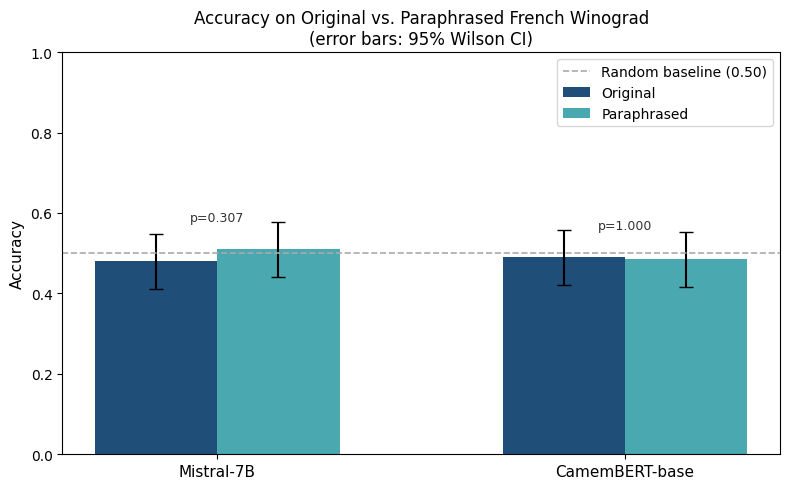

Saved: accuracy_comparison.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

DARK_BLUE = "#1f4e79"
TEAL      = "#4aa8b0"
ORANGE    = "#f4a742"
BASELINE_COLOR = "#aaaaaa"

# Figure 1: Accuracy comparison with 95% Wilson CIs
models = ["Mistral-7B", "CamemBERT-base"]

orig_accs  = [orig_acc_mistral, orig_acc_camembert]
para_accs  = [para_acc_mistral, para_acc_camembert]

orig_errs  = [
    [orig_acc_mistral - orig_ci_mistral[0],       orig_acc_camembert - orig_ci_camembert[0]],
    [orig_ci_mistral[1] - orig_acc_mistral,        orig_ci_camembert[1] - orig_acc_camembert]
]
para_errs  = [
    [para_acc_mistral - para_ci_mistral[0],       para_acc_camembert - para_ci_camembert[0]],
    [para_ci_mistral[1] - para_acc_mistral,        para_ci_camembert[1] - para_acc_camembert]
]

x = np.arange(len(models))
width = 0.30

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width/2, orig_accs, width, label="Original",
               color=DARK_BLUE, yerr=orig_errs, capsize=5, error_kw={"elinewidth": 1.5})
bars2 = ax.bar(x + width/2, para_accs, width, label="Paraphrased",
               color=TEAL, yerr=para_errs, capsize=5, error_kw={"elinewidth": 1.5})

# Baseline line
ax.axhline(y=0.50, color=BASELINE_COLOR, linestyle="--", linewidth=1.2, label="Random baseline (0.50)")

# Significance annotation
sig_labels = [
    f"p={pval_mistral:.3f}{'*' if pval_mistral < 0.05 else ''}",
    f"p={pval_camembert:.3f}{'*' if pval_camembert < 0.05 else ''}"
]
for i, (xpos, label) in enumerate(zip(x, sig_labels)):
    y_top = max(orig_accs[i], para_accs[i]) + 0.07
    ax.text(xpos, y_top, label, ha="center", fontsize=9, color="#333333")

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_ylim(0, 1)
ax.set_title("Accuracy on Original vs. Paraphrased French Winograd\n(error bars: 95% Wilson CI)", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "accuracy_comparison.png"), dpi=300)
plt.show()
print("Saved: accuracy_comparison.png")

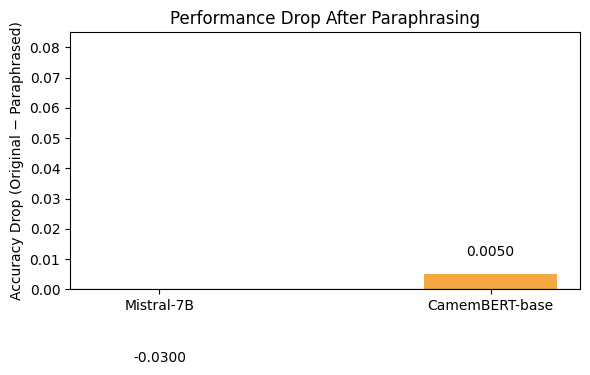

Saved: accuracy_drop.png


In [ ]:
# Figure 2: Accuracy drop
drops = [orig_acc_mistral - para_acc_mistral, orig_acc_camembert - para_acc_camembert]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(models, drops, color=[ORANGE, ORANGE], width=0.4)

# Label bars
for bar, d in zip(bars, drops):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{d:.4f}", ha="center", va="bottom", fontsize=10)

ax.set_ylabel("Accuracy Drop (Original − Paraphrased)", fontsize=10)
ax.set_title("Performance Drop After Paraphrasing", fontsize=12)
ax.set_ylim(0, max(drops) + 0.08)
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "accuracy_drop.png"), dpi=300)
plt.show()
print("Saved: accuracy_drop.png")

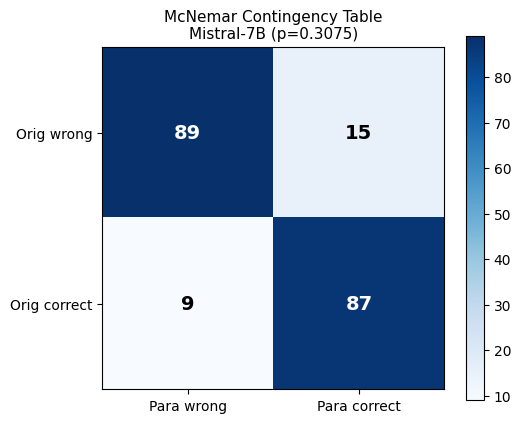

Saved: mcnemar_mistral.png


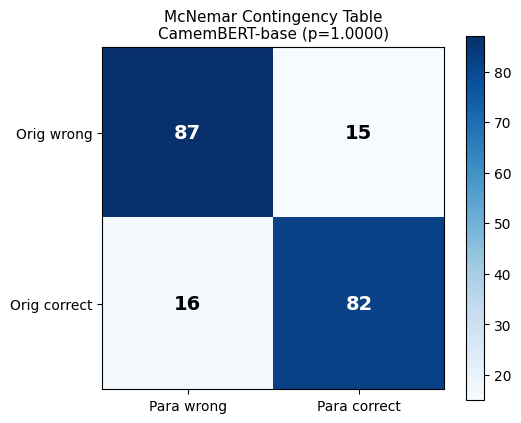

Saved: mcnemar_camembert.png


In [ ]:
# Figure 3 & 4: McNemar contingency heatmaps

def plot_mcnemar_heatmap(table, model_name, pval, filepath):
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    im = ax.imshow(table, cmap="Blues")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Para wrong", "Para correct"], fontsize=10)
    ax.set_yticklabels(["Orig wrong", "Orig correct"], fontsize=10)

    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(table[i, j]),
                    ha="center", va="center", fontsize=14, fontweight="bold",
                    color="white" if table[i, j] > table.max() * 0.6 else "black")

    sig_str = f" (p={pval:.4f}{'*' if pval < 0.05 else ''})"
    ax.set_title(f"McNemar Contingency Table\n{model_name}{sig_str}", fontsize=11)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(filepath, dpi=300)
    plt.show()

plot_mcnemar_heatmap(
    table_mistral, "Mistral-7B", pval_mistral,
    os.path.join(output_dir, "mcnemar_mistral.png")
)
print("Saved: mcnemar_mistral.png")

plot_mcnemar_heatmap(
    table_camembert, "CamemBERT-base", pval_camembert,
    os.path.join(output_dir, "mcnemar_camembert.png")
)
print("Saved: mcnemar_camembert.png")

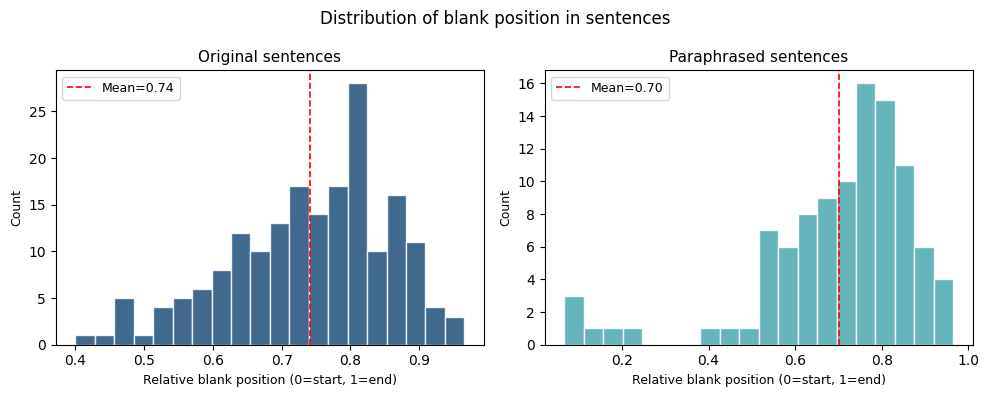

Saved: blank_position_distribution.png


In [ ]:
# Figure 5: Dataset blank-position distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

for ax, col, label, color in zip(
    axes,
    ["orig_blank_pos", "para_blank_pos"],
    ["Original sentences", "Paraphrased sentences"],
    [DARK_BLUE, TEAL]
):
    ax.hist(df[col].dropna(), bins=20, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Relative blank position (0=start, 1=end)", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    mean_val = df[col].mean()
    ax.axvline(mean_val, color="red", linestyle="--", linewidth=1.2, label=f"Mean={mean_val:.2f}")
    ax.legend(fontsize=9)

plt.suptitle("Distribution of blank position in sentences", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "blank_position_distribution.png"), dpi=300)
plt.show()
print("Saved: blank_position_distribution.png")

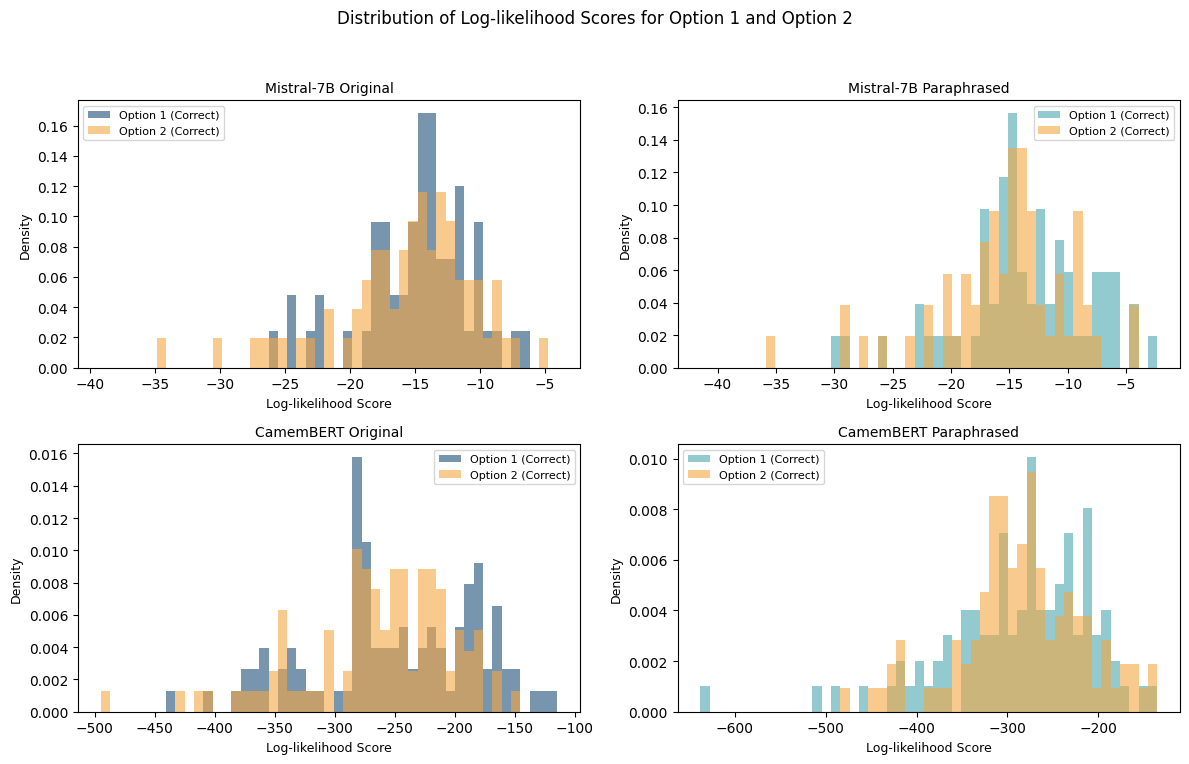

Saved: score_distributions.png


In [ ]:
# Figure 6: Log-likelihood score distributions (option1 vs option2, per model and condition)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

pairs = [
    (orig_results_mistral,    "Mistral-7B Original",     DARK_BLUE),
    (para_results_mistral,    "Mistral-7B Paraphrased",  TEAL),
    (orig_results_camembert,  "CamemBERT Original",      DARK_BLUE),
    (para_results_camembert,  "CamemBERT Paraphrased",   TEAL)
]

for i, (results_df, title, color) in enumerate(pairs):
    row = i // 2
    col = i % 2
    ax = axes[row, col]

    # Filter out infinite values before plotting histograms
    scores1_finite = results_df["score1"].replace([np.inf, -np.inf], np.nan).dropna()
    scores2_finite = results_df["score2"].replace([np.inf, -np.inf], np.nan).dropna()

    if not scores1_finite.empty and not scores2_finite.empty:
        # Determine common bins to ensure consistent x-axis scaling across histograms
        all_scores = pd.concat([scores1_finite, scores2_finite])
        min_score = all_scores.min()
        max_score = all_scores.max()
        if min_score == max_score: # Handle case where all scores are identical
            bins = [min_score - 1, min_score, min_score + 1]
        else:
            bins = np.linspace(min_score, max_score, 50)

        ax.hist(scores1_finite[results_df["correct"] == 1], bins=bins, color=color, alpha=0.6, label="Option 1 (Correct)", density=True)
        ax.hist(scores2_finite[results_df["correct"] == 0], bins=bins, color=ORANGE, alpha=0.6, label="Option 2 (Correct)", density=True)
        # Note: 'density=True' is used for better comparison of distributions, especially if counts differ

    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Log-likelihood Score", fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle("Distribution of Log-likelihood Scores for Option 1 and Option 2", fontsize=12)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(os.path.join(output_dir, "score_distributions.png"), dpi=300)
plt.show()
print("Saved: score_distributions.png")

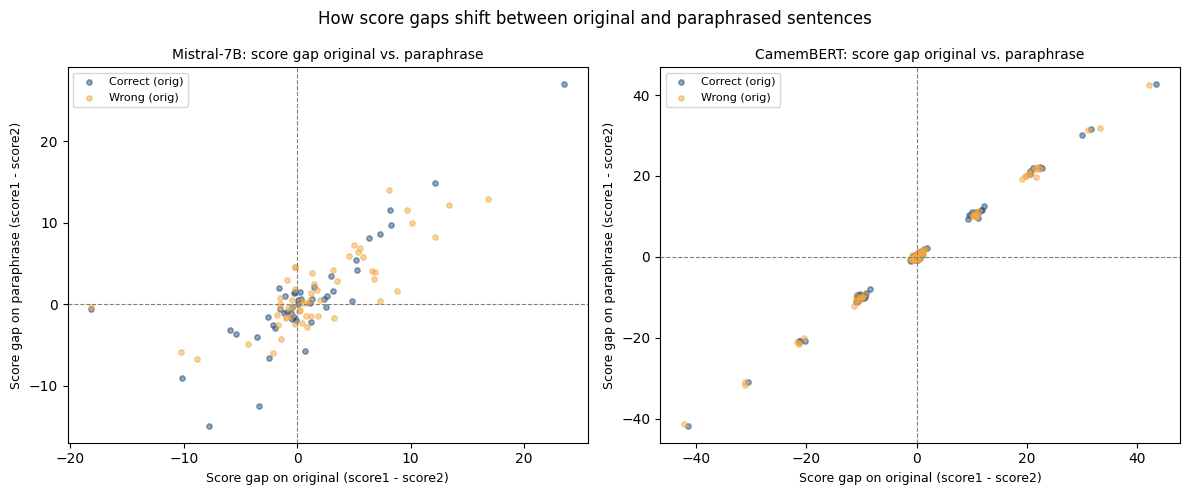

Saved: score_gap_scatter.png


In [ ]:
# Figure 7: Score gap scatter (score1 - score2) coloured by correctness
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (res_orig, res_para, model_label) in zip(axes, [
    (orig_results_mistral,   para_results_mistral,   "Mistral-7B"),
    (orig_results_camembert, para_results_camembert, "CamemBERT"),
]):
    gap_orig = res_orig["score1"] - res_orig["score2"]
    gap_para = res_para["score1"] - res_para["score2"]
    correct  = res_orig["correct"].values

    ax.scatter(gap_orig[correct == 1], gap_para[correct == 1],
               alpha=0.5, s=15, color=DARK_BLUE, label="Correct (orig)")
    ax.scatter(gap_orig[correct == 0], gap_para[correct == 0],
               alpha=0.5, s=15, color=ORANGE,    label="Wrong (orig)")
    ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
    ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Score gap on original (score1 - score2)", fontsize=9)
    ax.set_ylabel("Score gap on paraphrase (score1 - score2)", fontsize=9)
    ax.set_title(f"{model_label}: score gap original vs. paraphrase", fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle("How score gaps shift between original and paraphrased sentences", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "score_gap_scatter.png"), dpi=300)
plt.show()
print("Saved: score_gap_scatter.png")

In [ ]:
# Save all figures to Drive
target_dir = "/content/drive/MyDrive/Thesis_2025/new/figures"
os.makedirs(target_dir, exist_ok=True)

figure_files = [
    "accuracy_comparison.png",
    "accuracy_drop.png",
    "mcnemar_mistral.png",
    "mcnemar_camembert.png",
    "blank_position_distribution.png",
    "score_distributions.png",
    "score_gap_scatter.png",
]

for fname in figure_files:
    src_path = os.path.join(output_dir, fname)
    dst_path = os.path.join(target_dir, fname)
    if os.path.exists(src_path):
        shutil.copy(src_path, dst_path)
        print(f"Saved: {dst_path}")
    else:
        print(f"[WARNING] Not found: {fname} - run the cells above first")

Saved: /content/drive/MyDrive/Thesis_2025/new/figures/accuracy_comparison.png
Saved: /content/drive/MyDrive/Thesis_2025/new/figures/accuracy_drop.png
Saved: /content/drive/MyDrive/Thesis_2025/new/figures/mcnemar_mistral.png
Saved: /content/drive/MyDrive/Thesis_2025/new/figures/mcnemar_camembert.png
Saved: /content/drive/MyDrive/Thesis_2025/new/figures/blank_position_distribution.png
Saved: /content/drive/MyDrive/Thesis_2025/new/figures/score_distributions.png
Saved: /content/drive/MyDrive/Thesis_2025/new/figures/score_gap_scatter.png


## References

Amsili, P., & Seminck, O. (2017). A Google-proof collection of French Winograd schemas. *Proceedings of the 2nd Workshop on Coreference Resolution Beyond OntoNotes (CORBON 2017)*, 24-29.

Gevers, I., De Marez, V., De Bruyne, L., & Daelemans, W. (2025). WinoWhat: A parallel corpus of paraphrased WinoGrande sentences with common sense categorization. *Proceedings of the 29th Conference on Computational Natural Language Learning (CoNLL 2025)*, 68-80.

Sakaguchi, K., Le Bras, R., Bhagavatula, C., & Choi, Y. (2021). WinoGrande: An adversarial Winograd schema challenge at scale. *Communications of the ACM*, 64(9), 99-106.

Trinh, T. H., & Le, Q. V. (2018). A simple method for commonsense reasoning. *arXiv preprint arXiv:1806.02847*.

---

## Models

| Model | Type | Source |
|---|---|---|
| Mistral-7B-v0.1 | Causal LM | [mistralai/Mistral-7B-v0.1](https://huggingface.co/mistralai/Mistral-7B-v0.1) |
| CamemBERT-base | Masked LM | [camembert-base](https://huggingface.co/camembert-base) |

---

## Dataset

| Source | Instances | Format | Language |
|---|---|---|---|
| Amsili & Seminck (2017) | 100 | XML, converted to fill-in-the-blank | French (original) |
| Gevers et al. (2025), translated | 100 | Fill-in-the-blank | French (via DeepL) |
| **Total** | **200** | | |

---

## Reproducibility

Random seeds are fixed at the start of the notebook (`random.seed(0)`, `np.random.seed(1234)`, `torch.manual_seed(1234)`). All result CSVs and figures are saved to `/content/wino_results` and copied to Google Drive at `Thesis_2025/new/`.